In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Load the 1-Million-Row Trimmed Dataset
input_file = "data/US_Accidents_2016_2023_1M.csv"
df = pd.read_csv("../data/US_Accidents_2016_2023_1M.csv")

# 2. Extract Temporal Features from Start_Time before cleaning
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Month"] = df["Start_Time"].dt.month
df["Is_Rush_Hour"] = (
    df["Hour"].between(7, 9) | df["Hour"].between(16, 18)
).astype(int)

# Drop raw timestamp (no longer needed)
df = df.drop(columns=["Start_Time"])

# 3. Handle Domain-Specific Defaults Prior to Splitting
# Missing precipitation indicates dry conditions (0.0 inches)
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0.0)

# Binary infrastructure flags: fill blanks with False
infra_cols = [
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Stop",
    "Traffic_Signal",
]
df[infra_cols] = df[infra_cols].fillna(False).astype(int)

# 4. Feature Groups Definition
numeric_features = [
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Hour",
    "DayOfWeek",
    "Month",
]

categorical_features = ["Weather_Condition", "Sunrise_Sunset", "State"]

# Group rare weather labels into 'Other' to prevent sparse explosion
top_weather = df["Weather_Condition"].value_counts().nlargest(20).index
df["Weather_Condition"] = df["Weather_Condition"].apply(
    lambda x: x if x in top_weather or pd.isna(x) else "Other"
)

# 5. Split Dataset FIRST (Strictly Prevents Data Leakage for Viva 1)
X = df.drop(columns=["Severity"])
y = df["Severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 6. Define Imputation and Encoding Sub-Pipelines
numeric_pipeline = Pipeline(
    steps=[
        # Median avoids distortion from extreme sensor spikes
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        # Mode imputation for missing categories
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
        ("pass", "passthrough", infra_cols + ["Is_Rush_Hour"]),
    ]
)

# 7. Fit Preprocessing Strictly on Training Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original Records: {len(df):,}")
print(f"Training Feature Matrix: {X_train_processed.shape}")
print(f"Testing Feature Matrix: {X_test_processed.shape}")
print("No rows lost; distributions safely preserved.")

Original Records: 866,798
Training Feature Matrix: (693438, 92)
Testing Feature Matrix: (173360, 92)
No rows lost; distributions safely preserved.


In [2]:
# Verify distribution stability on Temperature(F)
raw_temp = X_train["Temperature(F)"]
imputed_temp = raw_temp.fillna(raw_temp.median())

summary_comparison = pd.DataFrame(
    {
        "Metric": ["Mean", "Median", "Standard Deviation", "Skewness"],
        "Before Imputation": [
            raw_temp.mean(),
            raw_temp.median(),
            raw_temp.std(),
            raw_temp.skew(),
        ],
        "After Imputation": [
            imputed_temp.mean(),
            imputed_temp.median(),
            imputed_temp.std(),
            imputed_temp.skew(),
        ],
    }
)

print(summary_comparison.to_string(index=False))

            Metric  Before Imputation  After Imputation
              Mean          61.585463         61.636314
            Median          64.000000         64.000000
Standard Deviation          18.901847         18.704962
          Skewness          -0.498530         -0.511715


Numerical Variable verfication

In [3]:
import numpy as np
import pandas as pd

# List of numeric columns that contain missing values
numeric_impute_cols = [
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
]

records = []

for col in numeric_impute_cols:
    raw_col = X_train[col]

    # Apply the corresponding imputation rule
    if col == "Precipitation(in)":
        imputed_col = raw_col.fillna(0.0)
    else:
        imputed_col = raw_col.fillna(raw_col.median())

    # Calculate statistics
    mean_raw, mean_imp = raw_col.mean(), imputed_col.mean()
    med_raw, med_imp = raw_col.median(), imputed_col.median()
    std_raw, std_imp = raw_col.std(), imputed_col.std()
    skew_raw, skew_imp = raw_col.skew(), imputed_col.skew()

    # Calculate percentage change in mean
    mean_shift_pct = abs(mean_imp - mean_raw) / (abs(mean_raw) + 1e-9) * 100
    std_shift_pct = abs(std_imp - std_raw) / (abs(std_raw) + 1e-9) * 100

    records.append(
        {
            "Feature": col,
            "Null Count": raw_col.isna().sum(),
            "Null %": f"{(raw_col.isna().sum() / len(raw_col)) * 100:.2f}%",
            "Mean (Before)": round(mean_raw, 3),
            "Mean (After)": round(mean_imp, 3),
            "Mean Shift %": f"{mean_shift_pct:.2f}%",
            "Std (Before)": round(std_raw, 3),
            "Std (After)": round(std_imp, 3),
            "Std Shift %": f"{std_shift_pct:.2f}%",
            "Median (B/A)": f"{med_raw:.1f} / {med_imp:.1f}",
        }
    )

numeric_validation_df = pd.DataFrame(records)
print(numeric_validation_df.to_string(index=False))

          Feature  Null Count Null %  Mean (Before)  Mean (After) Mean Shift %  Std (Before)  Std (After) Std Shift % Median (B/A)
   Temperature(F)       14604  2.11%         61.585        61.636        0.08%        18.902       18.705       1.04%  64.0 / 64.0
      Humidity(%)       15529  2.24%         65.093        65.136        0.07%        22.789       22.534       1.12%  67.0 / 67.0
     Pressure(in)       12445  1.79%         29.566        29.572        0.02%         0.984        0.976       0.82%  29.9 / 29.9
   Visibility(mi)       15769  2.27%          9.100         9.121        0.22%         2.709        2.681       1.02%  10.0 / 10.0
  Wind_Speed(mph)       56367  8.13%          7.710         7.652        0.75%         5.296        5.080       4.08%    7.0 / 7.0
Precipitation(in)           0  0.00%          0.006         0.006        0.00%         0.099        0.099       0.00%    0.0 / 0.0


Categorical Variable Verification

In [4]:
categorical_cols = ["Weather_Condition", "Sunrise_Sunset"]

for col in categorical_cols:
    raw_col = X_train[col]
    mode_val = raw_col.mode()[0]
    imputed_col = raw_col.fillna(mode_val)

    # Calculate percentage distributions before and after
    dist_before = (
        raw_col.value_counts(normalize=True, dropna=True) * 100
    ).round(2)
    dist_after = (imputed_col.value_counts(normalize=True) * 100).round(2)

    cat_comparison = pd.DataFrame(
        {"% Before Imputation": dist_before, "% After Imputation": dist_after}
    ).fillna(0.0)

    # Check top 5 categories
    print(f"\n--- Distribution Verification: {col} (Mode: '{mode_val}') ---")
    print(f"Missing records: {raw_col.isna().sum():,}")
    print(cat_comparison.head(5).to_string())


--- Distribution Verification: Weather_Condition (Mode: 'Fair') ---
Missing records: 15,495
                   % Before Imputation  % After Imputation
Weather_Condition                                         
Fair                             31.54               33.07
Mostly Cloudy                    13.49               13.19
Clear                            12.42               12.14
Cloudy                           10.29               10.06
Partly Cloudy                     9.36                9.15

--- Distribution Verification: Sunrise_Sunset (Mode: 'Day') ---
Missing records: 1,535
                % Before Imputation  % After Imputation
Sunrise_Sunset                                         
Day                           69.37               69.44
Night                         30.63               30.56


Road Infrastructure Flags Verification

In [5]:
infra_cols = [
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Stop",
    "Traffic_Signal",
]

infra_records = []
for col in infra_cols:
    raw_col = X_train[col]
    imputed_col = raw_col.fillna(False).astype(bool)

    infra_records.append(
        {
            "Infrastructure Flag": col,
            "Nulls": raw_col.isna().sum(),
            "% True (Before)": f"{(raw_col.mean()) * 100:.2f}%",
            "% True (After)": f"{(imputed_col.mean()) * 100:.2f}%",
        }
    )

infra_df = pd.DataFrame(infra_records)
print("\n--- Infrastructure Flags Imputation Verification ---")
print(infra_df.to_string(index=False))


--- Infrastructure Flags Imputation Verification ---
Infrastructure Flag  Nulls % True (Before) % True (After)
            Amenity      0           1.27%          1.27%
               Bump      0           0.04%          0.04%
           Crossing      0          11.66%         11.66%
           Give_Way      0           0.51%          0.51%
           Junction      0           7.49%          7.49%
            No_Exit      0           0.24%          0.24%
            Railway      0           0.89%          0.89%
         Roundabout      0           0.00%          0.00%
               Stop      0           2.78%          2.78%
     Traffic_Signal      0          15.94%         15.94%


Visual Verification (Side-by-Side KDE Plots)

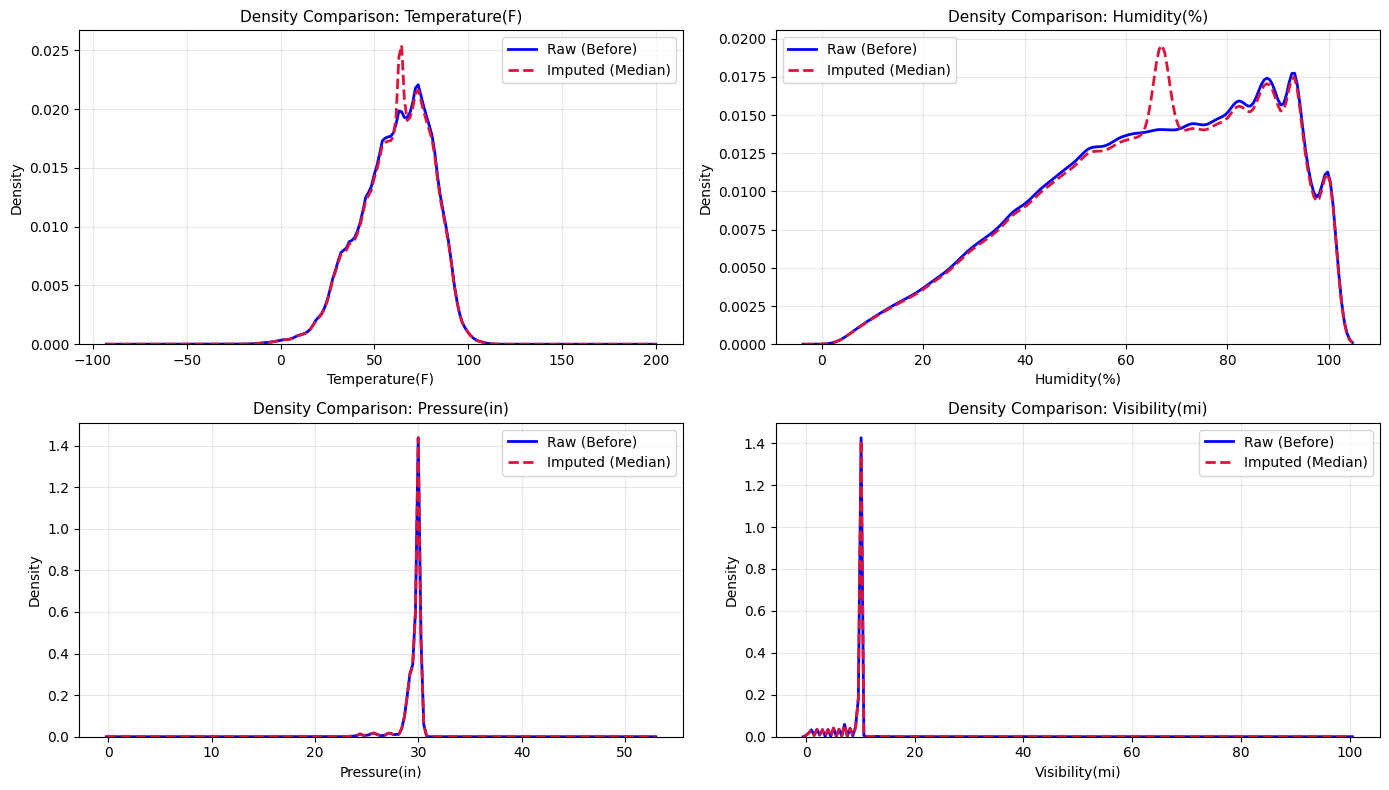

Plots saved as 'feature_distribution_verification.png'


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = [
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    raw = X_train[col].dropna()
    imputed = X_train[col].fillna(X_train[col].median())

    sns.kdeplot(
        raw, ax=axes[i], label="Raw (Before)", color="blue", linewidth=2
    )
    sns.kdeplot(
        imputed,
        ax=axes[i],
        label="Imputed (Median)",
        color="crimson",
        linestyle="--",
        linewidth=2,
    )

    axes[i].set_title(f"Density Comparison: {col}", fontsize=11)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("feature_distribution_verification.png", dpi=300)
plt.show()
print("Plots saved as 'feature_distribution_verification.png'")

Weather_Condition and Sunrise_Sunset check

In [7]:
# Run this quick check for your categorical mode imputation
for col in ["Weather_Condition", "Sunrise_Sunset"]:
    mode_val = X_train[col].mode()[0]
    raw_col = X_train[col]
    imputed_col = raw_col.fillna(mode_val)

    print(
        f"\n{col} Imputation Check (Nulls: {raw_col.isna().sum():,}, Mode: '{mode_val}'):"
    )
    df_check = pd.DataFrame(
        {
            "Raw %": (raw_col.value_counts(normalize=True) * 100).round(2),
            "Imputed %": (
                imputed_col.value_counts(normalize=True) * 100
            ).round(2),
        }
    )
    print(df_check.head(4).to_string())


Weather_Condition Imputation Check (Nulls: 15,495, Mode: 'Fair'):
                   Raw %  Imputed %
Weather_Condition                  
Fair               31.54      33.07
Mostly Cloudy      13.49      13.19
Clear              12.42      12.14
Cloudy             10.29      10.06

Sunrise_Sunset Imputation Check (Nulls: 1,535, Mode: 'Day'):
                Raw %  Imputed %
Sunrise_Sunset                  
Day             69.37      69.44
Night           30.63      30.56


Model Development Setup

In [8]:
import joblib

# 1. Save fitted pipeline for backend integration (Stages 9 & 10)
joblib.dump(preprocessor, "../models/preprocessor.joblib")
print("Saved fitted ColumnTransformer to 'preprocessor.joblib'")

# 2. Extract internal working sample for Stage 6 model training
# Training 4 algorithms across 1M rows on local hardware can take hours;
# an internal 100k stratified working slice ensures fast CV convergence.
train_sample_idx = (
    X_train.groupby(y_train, group_keys=False)
    .apply(lambda s: s.sample(frac=0.125, random_state=42))
    .index
)

X_train_slice = X_train.loc[train_sample_idx]
y_train_slice = y_train.loc[train_sample_idx]

print(f"Working training slice ready: {X_train_slice.shape[0]:,} rows")

Saved fitted ColumnTransformer to 'preprocessor.joblib'
Working training slice ready: 86,680 rows
